<a href="https://colab.research.google.com/github/NurAyuL27/PCVK_Genap_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2: Import Library**

In [5]:
# Import library yang diperlukan
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Mount Google Drive (jika menggunakan Google Colab)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**3: Histogram Manual**

/tmp/ipython-input-394566286.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipython-input-394566286.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipython-input-394566286.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


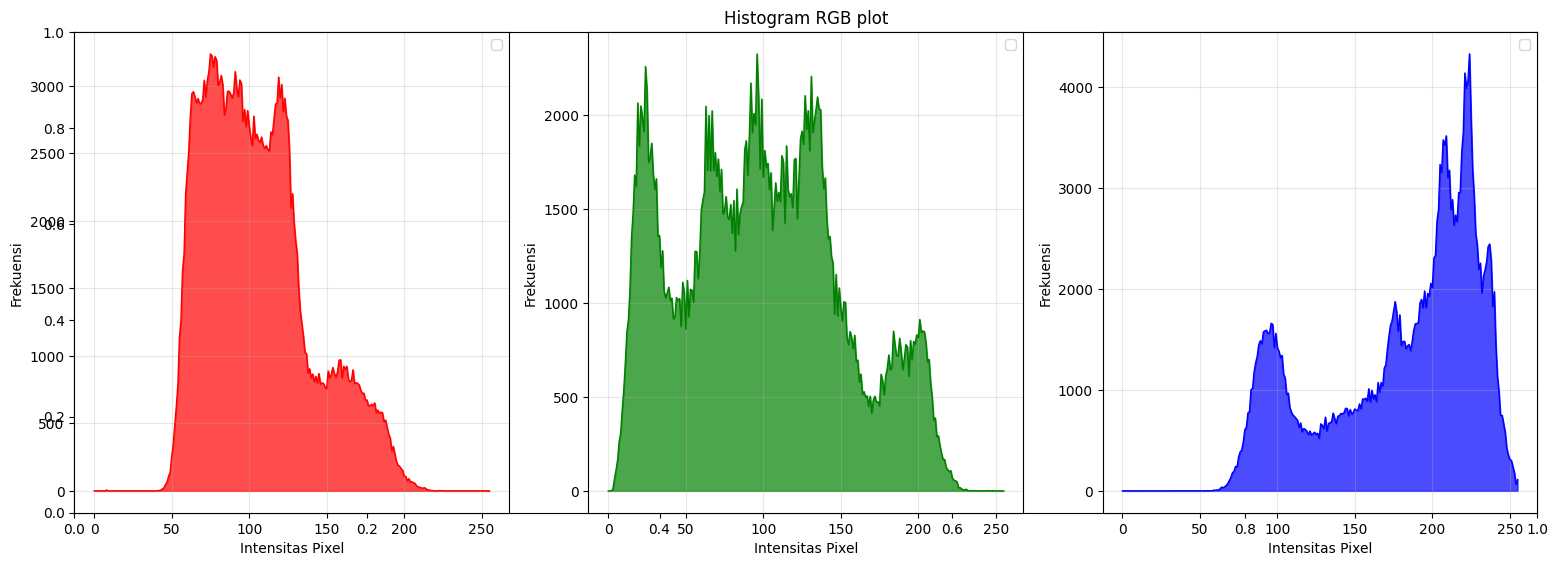

In [24]:
def manual_histogram_area(image):
    # Untuk grayscale image
    if len(image.shape) == 2:
        hist = np.zeros(256, dtype=int)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                intensity = image[i, j]
                hist[intensity] += 1
        return hist, None, None

    # Untuk color image (RGB)
    else:
        hist_r = np.zeros(256, dtype=int)
        hist_g = np.zeros(256, dtype=int)
        hist_b = np.zeros(256, dtype=int)

        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                b, g, r = image[i, j]
                hist_b[b] += 1
                hist_g[g] += 1
                hist_r[r] += 1

        return hist_r, hist_g, hist_b

# Load gambar lena.jpg
lena_path = '/content/drive/MyDrive/lena.png'  # Sesuaikan path
lena = cv.imread(lena_path)
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

# Membuat histogram manual
hist_r_manual, hist_g_manual, hist_b_manual = manual_histogram_area(lena_rgb)


# Plot histogram manual dengan AREA FILL
plt.figure(figsize=(16, 6))
plt.title('Histogram RGB plot')

# Histogram Red Channel dengan area fill
plt.subplot(1, 3, 1)
x = np.arange(256)
plt.fill_between(x, hist_r_manual, alpha=0.7, color='red')
plt.plot(x, hist_r_manual, color='red', linewidth=1)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.legend()

# Histogram Green Channel dengan area fill
plt.subplot(1, 3, 2)
plt.fill_between(x, hist_g_manual, alpha=0.7, color='green')
plt.plot(x, hist_g_manual, color='green', linewidth=1)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.legend()

# Histogram Blue Channel dengan area fill
plt.subplot(1, 3, 3)
plt.fill_between(x, hist_b_manual, alpha=0.7, color='blue')
plt.plot(x, hist_b_manual, color='blue', linewidth=1)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**4: Histogram NumPy**

/tmp/ipython-input-15732967.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipython-input-15732967.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipython-input-15732967.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


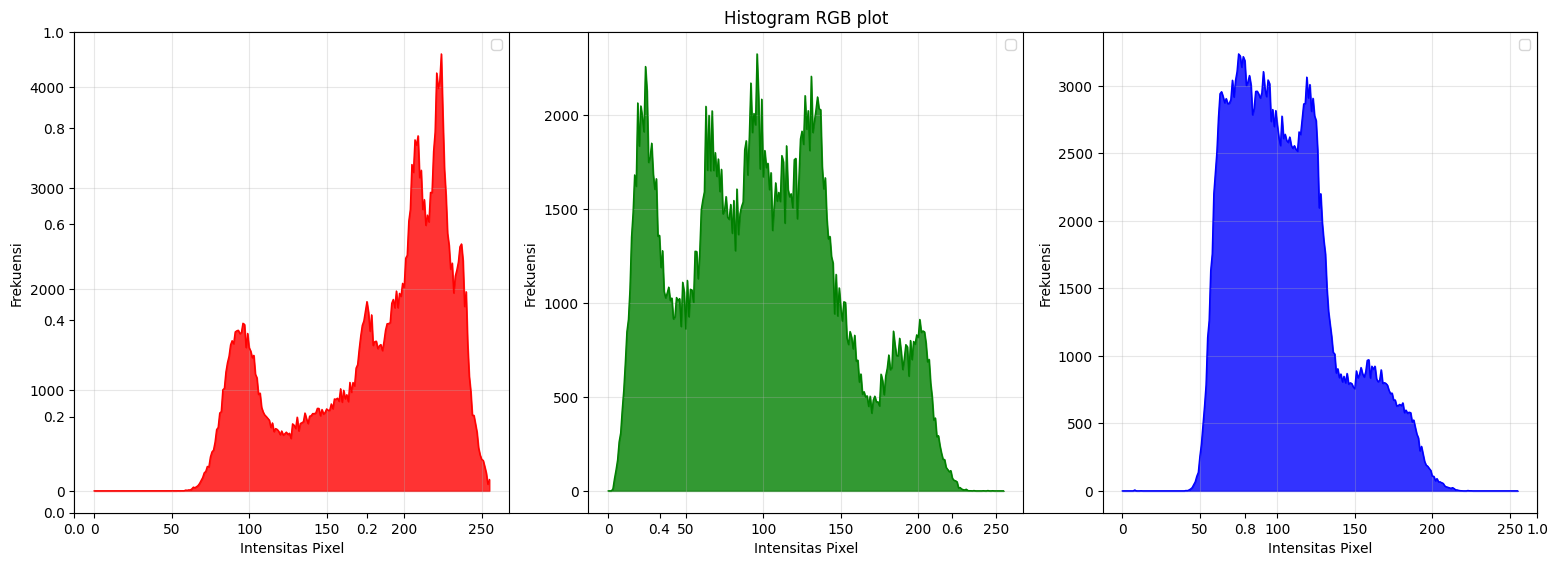

Perbandingan histogram manual vs NumPy:
Red channel - MSE: 2856550.5625
Green channel - MSE: 0.0
Blue channel - MSE: 2856550.5625


In [26]:
def numpy_histogram(image):
    # Untuk grayscale image
    if len(image.shape) == 2:
        hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])
        return hist, None, None

    # Untuk color image (RGB)
    else:
        hist_r, bins_r = np.histogram(image[:,:,0].flatten(), bins=256, range=[0, 256])
        hist_g, bins_g = np.histogram(image[:,:,1].flatten(), bins=256, range=[0, 256])
        hist_b, bins_b = np.histogram(image[:,:,2].flatten(), bins=256, range=[0, 256])

        return hist_r, hist_g, hist_b

# Membuat histogram dengan NumPy
hist_r_numpy, hist_g_numpy, hist_b_numpy = numpy_histogram(lena_rgb)

# Plot histogram NumPy
plt.figure(figsize=(16, 6))
plt.title('Histogram RGB plot')

# Histogram Red Channel dengan area fill
plt.subplot(1, 3, 1)
x = np.arange(256)
plt.fill_between(x, hist_r_numpy, alpha=0.8, color='red')
plt.plot(x, hist_r_numpy, color='red', linewidth=1)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.legend()

# Histogram Green Channel dengan area fill
plt.subplot(1, 3, 2)
plt.fill_between(x, hist_g_numpy, alpha=0.8, color='green')
plt.plot(x, hist_g_numpy, color='green', linewidth=1)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.legend()

# Histogram Blue Channel dengan area fill
plt.subplot(1, 3, 3)
plt.fill_between(x, hist_b_numpy, alpha=0.8, color='blue')
plt.plot(x, hist_b_numpy, color='blue', linewidth=1)
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Membandingkan hasil numpy dan NumPy
print("Perbandingan histogram manual vs NumPy:")
print(f"Red channel - MSE: {np.mean((hist_r_manual - hist_r_numpy)**2)}")
print(f"Green channel - MSE: {np.mean((hist_g_manual - hist_g_numpy)**2)}")
print(f"Blue channel - MSE: {np.mean((hist_b_manual - hist_b_numpy)**2)}")

**5: Histogram Equalization Manual**

**6: Histogram Equalization CV2**

**7: Pemetaan ke 8 Warna**

**8: Dithering Floyd-Steinberg**

**9: Kombinasi HE + Dithering**